# Korea, US, and Crypto Multi-Market Decomposition

This notebook combines Korean equities, US ETFs, and crypto pairs. The purpose is to show how De-Time features can support cross-market timing and regime research. Crypto is traded 24/7, while equity markets have exchange calendars; production research must treat calendars separately.

**Default decomposition:** `ROBUST_STL` with a 63-trading-day period, computed walk-forward where signals are backtested.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.quant_trading.data import fetch_yahoo_prices, fetch_yahoo_ohlcv, data_audit_report, DEFAULT_UNIVERSES
from examples.quant_trading.features import decompose_one_series, walkforward_decompose, build_feature_table
from examples.quant_trading.signals import (
    trend_pullback_signals,
    residual_mean_reversion_signals,
    turtle_donchian_signals,
    pair_trading_weights,
    cross_sectional_rotation_weights,
    residual_stress_filter,
)
from examples.quant_trading.backtest import backtest_weights, backtest_long_short_signals, summarize_returns

DATA_CACHE = Path("examples/quant_trading/data/cache")
QUANT_METHOD = "ROBUST_STL"
QUANT_PERIOD = 63


In [2]:
tickers = ["005930.KS", "000660.KS", "035420.KS", "SPY", "QQQ", "BTC-USD", "ETH-USD"]
prices = fetch_yahoo_prices(tickers, start="2018-01-01", cache_dir=DATA_CACHE, min_observations=500)
data_audit_report(prices)

,ticker,first_timestamp,last_timestamp,observations,missing_ratio,min_price,max_price
0,005930.KS,2018-01-01,2026-05-22,3064,0.0,31213.433594,2.995000e+05
1,000660.KS,2018-01-01,2026-05-22,3064,0.0,53071.500000,1.976000e+06
2,035420.KS,2018-01-01,2026-05-22,3064,0.0,103009.718750,4.418342e+05
3,SPY,2018-01-01,2026-05-22,3064,0.0,204.944901,7.481700e+02
4,QQQ,2018-01-01,2026-05-22,3064,0.0,137.163361,7.204600e+02
5,BTC-USD,2018-01-01,2026-05-22,3064,0.0,3236.761719,1.247525e+05
6,ETH-USD,2018-01-01,2026-05-22,3064,0.0,84.308296,4.831349e+03


In [3]:
features = walkforward_decompose(prices, method=QUANT_METHOD, period=QUANT_PERIOD, train_window=252, step=21)
regime = residual_stress_filter(prices, features, max_abs_residual_z=3.0, require_positive_trend=False)
regime.tail()

,005930.KS,000660.KS,035420.KS,SPY,QQQ,BTC-USD,ETH-USD
Date,,,,,,,
2026-05-18,True,True,True,True,True,True,True
2026-05-19,True,True,True,True,True,True,True
2026-05-20,True,True,True,True,True,True,True
2026-05-21,True,True,True,True,True,True,True
2026-05-22,True,True,True,True,True,True,True


## Visualization: residual-stress regime map

The heatmap shows when each asset passes or fails the residual-stress filter across markets.

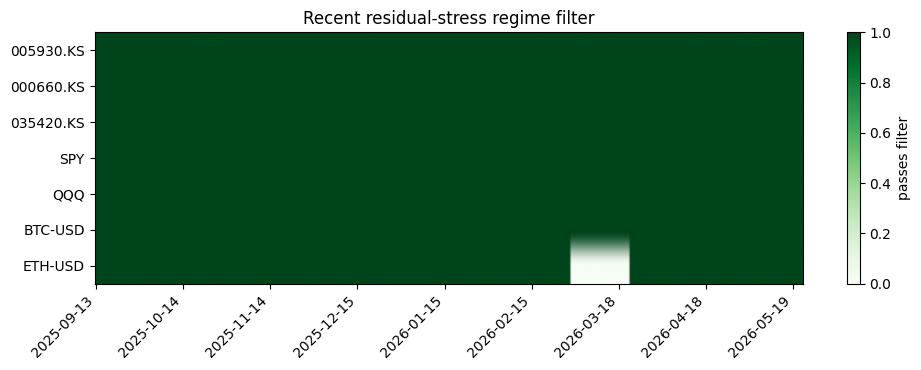

In [4]:
recent_regime = regime.tail(252).astype(float).T
fig, ax = plt.subplots(figsize=(10, 3.8))
im = ax.imshow(recent_regime.to_numpy(), aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_yticks(range(len(recent_regime.index)))
ax.set_yticklabels(recent_regime.index)
tick_step = max(1, len(recent_regime.columns) // 8)
xticks = list(range(0, len(recent_regime.columns), tick_step))
ax.set_xticks(xticks)
ax.set_xticklabels([str(recent_regime.columns[i].date()) if hasattr(recent_regime.columns[i], "date") else str(recent_regime.columns[i])[:10] for i in xticks], rotation=45, ha="right")
ax.set_title("Recent residual-stress regime filter")
fig.colorbar(im, ax=ax, label="passes filter")
plt.tight_layout()
plt.show()


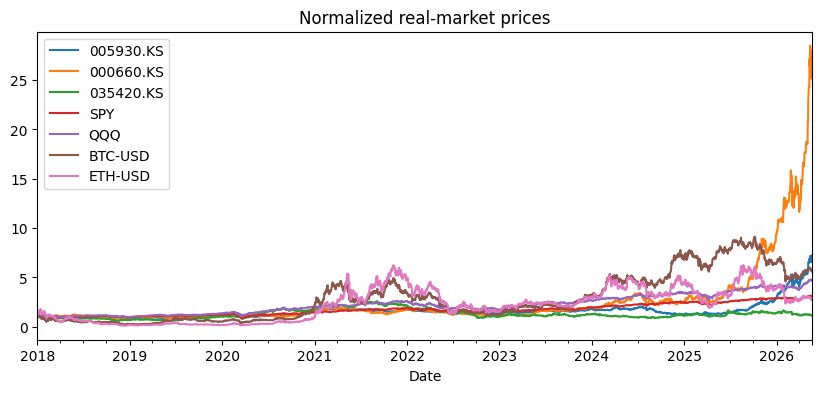

In [5]:
normalized = prices / prices.iloc[0]
normalized.plot(figsize=(10, 4), title="Normalized real-market prices")
plt.show()

## Visualization: cross-market return correlation

The correlation heatmap makes the Korea, US, and crypto alignment assumptions visible.

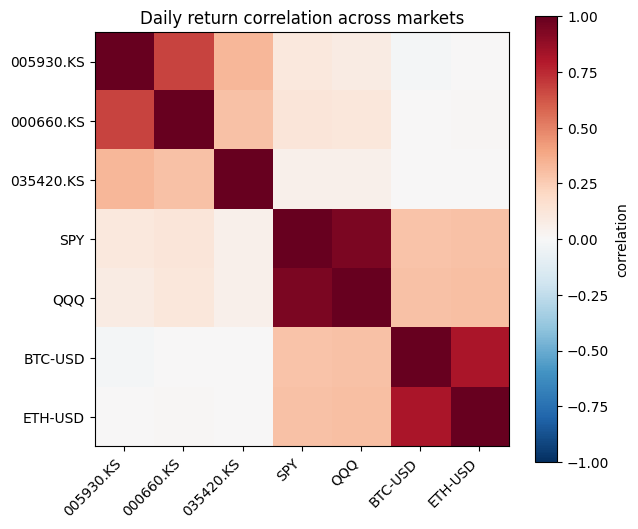

In [6]:
correlation = prices.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="all").corr()
fig, ax = plt.subplots(figsize=(6.5, 5.5))
absmax = max(float(np.nanmax(np.abs(correlation.to_numpy()))), 1e-9)
im = ax.imshow(correlation.to_numpy(), cmap="RdBu_r", vmin=-absmax, vmax=absmax)
ax.set_xticks(range(len(correlation.columns)))
ax.set_xticklabels(correlation.columns, rotation=45, ha="right")
ax.set_yticks(range(len(correlation.index)))
ax.set_yticklabels(correlation.index)
ax.set_title("Daily return correlation across markets")
fig.colorbar(im, ax=ax, label="correlation")
plt.tight_layout()
plt.show()


Research extensions: cross-market lead-lag, shared semiconductor cycle, crypto risk-on/risk-off filter, and FX-adjusted Korea/US relative value.